# ⚡ Checkpoint 4 — Limites, Desempenho de APIs e Streamlit
**Disciplina:** Differentiated Problem Solving (DPS)  
**Instituição:** FIAP — 2026  
**Docente:** Prof. Jones Egydio  
**Curso:** Engenharia de Software  
**Tema:** Projeto Aplicado de Modelagem Matemática — *Da observação de desempenho à tomada de decisão técnica*  
**Pontuação Total:** 10,0 pontos  

### 👥 Integrantes do Grupo:
- **Thiago Gomes Nascimento** — RM: 569436
- **Gabriel Henrique Ongarelli Reis** — RM: 572636
- **Vinicius Scalone Ramires** — RM: 573783
- **Matheus de Amorim Brito** — RM: 572435
- **Eduardo Felix Frois Silva** — RM: 574103

---

## 🏢 1. Contexto do Problema e Dados Empíricos

### 1.1. Contexto do Challenge
A empresa parceira do Challenge (**Jovi / Vivo**) utiliza ecossistemas digitais em nuvem de alta concorrência para atender milhões de clientes simultâneos. Um dos componentes mais críticos dessa infraestrutura é o **vivoCloud Storage API**, um microsserviço responsável por receber requisições de upload, sincronização e persistência de dados.

### 1.2. Problema de Desempenho Observado
Durante a realização de testes de carga controlados, a equipe de Engenharia de Software e *Site Reliability Engineering* (SRE) constatou que o **tempo médio de resposta (latência)** da API aumenta conforme cresce a taxa de requisições recebidas por segundo ($x$).
- Em regimes de baixa e média carga, o tempo de resposta permanece baixo, estável e previsível.
- Contudo, à medida que a carga se aproxima da capacidade máxima de processamento do nó de infraestrutura ($\approx 50\text{ req/s}$), o tempo de resposta **cresce de forma desproporcional e explosiva**, comprometendo a experiência do usuário, violando os Acordos de Nível de Serviço (**SLA**) e colocando em risco a disponibilidade de todo o ecossistema.

### 1.3. Resultados Observados no Teste de Carga
| Carga ($x$ em req/s) | Tempo Médio de Resposta Medido ($y$ em ms) |
| :---: | :---: |
| **10** | 25 |
| **20** | 33 |
| **30** | 50 |
| **35** | 67 |
| **40** | 100 |
| **45** | 200 |
| **48** | 500 |

O objetivo deste projeto é modelar matematicamente esse comportamento com o auxílio do **Conceito de Limites**, implementar a solução computacional em Python/SymPy, validar o ajuste empírico por regressão não linear e disponibilizar uma **aplicação interativa em Streamlit** para apoiar decisões estratégicas de arquitetura e infraestrutura de software.


---

## 🧮 2. Construção do Modelo Matemático (Critério 3.1 — 2,0 pontos)

### a) Definição das Variáveis e Domínios
- **Variável Independente ($x$):** Taxa de requisições por segundo recebidas pelo endpoint da API ($\text{req/s}$).
- **Variável Dependente ($f(x)$ ou $T(x)$):** Tempo médio de resposta / latência da API em milissegundos ($\text{ms}$).
- **Domínio Matemático:**  
  $$\text{Dom}(f) = \{x \in \mathbb{R} \mid x \neq 50\}$$  
  Algebricamente, a função é contínua e definida em toda a reta real exceto em $x = 50$, onde ocorre anulação do denominador (divisão por zero).
- **Domínio Válido no Contexto do Sistema (Domínio Operacional):**  
  $$\text{Dom}_{\text{operacional}} = [0, 50) \text{ req/s}$$
  *Fundamentação Física e Computacional:*
  1. $x < 0$ é fisicamente impossível no mundo real (não existe taxa negativa de requisições).
  2. $x = 50$ causa indeterminação matemática e colapso operacional (fila infinita de espera).
  3. $x > 50$ geraria tempos de resposta negativos pelo modelo algébrico, o que não possui significado no processamento de software.

### b) Construção da Função Matemática
Fundamentada na **Teoria de Filas (Modelo $M/M/1$ de Kleinrock)**, o tempo médio de permanência no sistema sob taxa de chegada $\lambda = x$ e taxa de atendimento $\mu = 50\text{ req/s}$ é expresso por $W = \frac{1}{\mu - \lambda}$ (em segundos). Aplicando o fator de conversão de escala para milissegundos ($1000\text{ ms/s}$):

$$f(x) = \frac{1000}{50 - x}$$

### c) Justificativa da Escolha da Função Racional
1. **Representação da Barreira Assintótica:** Recursos computacionais (núcleos de CPU, *threads* de I/O, memória RAM, conexões de banco de dados) são estritamente finitos. Quando a taxa de requisições se aproxima da taxa máxima de serviço ($\mu = 50$), o tempo de enfileiramento cresce assintoticamente ao infinito. Modelos polinomiais ou lineares falham categoricamente por não possuírem assíntotas verticais.
2. **Aderência Perfeita aos Dados Empíricos:**
   - $f(10) = \frac{1000}{50 - 10} = \frac{1000}{40} = 25.00\text{ ms}$ (Erro: $0.0\%$)
   - $f(20) = \frac{1000}{50 - 20} = \frac{1000}{30} = 33.33\text{ ms} \approx 33\text{ ms}$ (Erro: $1.0\%$)
   - $f(30) = \frac{1000}{50 - 30} = \frac{1000}{20} = 50.00\text{ ms}$ (Erro: $0.0\%$)
   - $f(35) = \frac{1000}{50 - 35} = \frac{1000}{15} = 66.67\text{ ms} \approx 67\text{ ms}$ (Erro: $0.5\%$)
   - $f(40) = \frac{1000}{50 - 40} = \frac{1000}{10} = 100.00\text{ ms}$ (Erro: $0.0\%$)
   - $f(45) = \frac{1000}{50 - 45} = \frac{1000}{5} = 200.00\text{ ms}$ (Erro: $0.0\%$)
   - $f(48) = \frac{1000}{50 - 48} = \frac{1000}{2} = 500.00\text{ ms}$ (Erro: $0.0\%$)

### d) Identificação do Ponto e Região Crítica
- **Ponto Crítico:** $x = 50\text{ req/s}$ (ponto de descontinuidade infinita / singularidade assintótica).
- **Região Crítica:** Intervalo $[45, 50)\text{ req/s}$ (utilização $\ge 90\%$, onde pequenas flutuações de tráfego disparam a latência para milhares de milissegundos).

### e) Significado Técnico no Contexto da Engenharia de Software
Representa o esgotamento completo da capacidade de *throughput* do nó de computação: saturação do *pool* de *threads* do servidor web (ex.: Tomcat / Uvicorn / NGINX), esgotamento de conexões TCP, acúmulo no buffer de sockets e disparo de erros `HTTP 504 Gateway Timeout` por estouro de *timeout* dos clientes.

---

> ### 📌 **Questão Obrigatória 3.1**
> **Pergunta:** *A capacidade estimada de 50 requisições por segundo significa necessariamente que o sistema consegue operar normalmente com exatamente 50 requisições por segundo? Fundamente a resposta utilizando o modelo construído.*  
> 
> **Resposta Fundamentada:** **Não, categoricamente não.** O sistema é absolutamente incapaz de operar com estabilidade em exatamente $50\text{ req/s}$. Avaliando o modelo analítico no ponto $x = 50$:
> $$f(50) = \frac{1000}{50 - 50} = \frac{1000}{0}$$
> Temos uma divisão por zero (indeterminação matemática). Pelo limite lateral $\lim_{x \to 50^-} f(x) = +\infty$, quando a taxa de chegada atinge a capacidade máxima do servidor, a fila de espera cresce infinitamente sem nunca ser drenada. Operacionalmente, isso provoca estouro de memória (*Out Of Memory*), esgotamento de conexões e travamento total da aplicação (*crash*).


In [1]:
# dps_streamlit_canary = "vega_8241"
# Importação das bibliotecas científicas essenciais
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import display, HTML

# Configurações visuais do Matplotlib / Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# 1. Definição simbólica da variável x e da função analítica f(x) com SymPy
x = sp.Symbol('x', real=True)
f = 1000 / (50 - x)

print("="*65)
print("       MODELO MATEMÁTICO ANALÍTICO SIMBÓLICO (SymPy)")
print("="*65)
sp.pprint(f)

# 2. Validação Estatística por Regressão Não Linear (Curve Fitting)
cargas_exp = np.array([10, 20, 30, 35, 40, 45, 48], dtype=float)
tempos_exp = np.array([25, 33, 50, 67, 100, 200, 500], dtype=float)

def modelo_generico(x_in, k_param, mu_param):
    return k_param / (mu_param - x_in)

popt, pcov = curve_fit(modelo_generico, cargas_exp, tempos_exp, p0=[1000, 50])
k_ajustado, mu_ajustado = popt
tempos_preditos = modelo_generico(cargas_exp, *popt)
r2 = r2_score(tempos_exp, tempos_preditos)
mse = mean_squared_error(tempos_exp, tempos_preditos)

print("\n" + "="*65)
print("     VALIDAÇÃO ESTATÍSTICA POR MÍNIMOS QUADRADOS (Curve Fit)")
print("="*65)
print(f"Parâmetro k ajustado:        {k_ajustado:.4f} (Teórico: 1000.0)")
print(f"Capacidade mu ajustada:      {mu_ajustado:.4f} req/s (Teórico: 50.0 req/s)")
print(f"Coeficiente R²:              {r2:.6f} (Ajuste quase perfeito > 0.9999)")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print("="*65)


       MODELO MATEMÁTICO ANALÍTICO SIMBÓLICO (SymPy)
 1000 
──────
50 - x

     VALIDAÇÃO ESTATÍSTICA POR MÍNIMOS QUADRADOS (Curve Fit)
Parâmetro k ajustado:        1000.3238 (Teórico: 1000.0)
Capacidade mu ajustada:      50.0007 req/s (Teórico: 50.0 req/s)
Coeficiente R²:              0.999999 (Ajuste quase perfeito > 0.9999)
Erro Quadrático Médio (MSE): 0.0313


---

## 📈 3. Análise Matemática Utilizando Limites e Cálculo Diferencial (Critério 3.2 — 2,0 pontos)

Para investigar rigorosamente o comportamento da API em todas as regiões, realizamos a análise matemática por limites e derivadas:

### a) e b) Cálculo e Interpretação dos Limites Simbólicos

| Limite Simbólico | Valor | Classificação | Significado Gráfico | Significado Operacional no Sistema Real |
| :--- | :---: | :---: | :--- | :--- |
| $\lim_{x \to 0^+} \frac{1000}{50 - x}$ | **$20\text{ ms}$** | **Finito** | Intercepto com o eixo $y$ em $(0, 20)$. | **Latência em repouso (baseline):** Tempo de processamento e overhead de rede sem contenção de recursos. |
| $\lim_{x \to 50^-} \frac{1000}{50 - x}$ | **$+\infty$** | **Infinito Positivo** | A curva diverge verticalmente ao infinito ao se aproximar de $x = 50$ pela esquerda. | **Colapso por saturação:** Fila de espera cresce sem limites, gerando estouro de memória e *timeouts*. |
| $\lim_{x \to 50^+} \frac{1000}{50 - x}$ | **$-\infty$** | **Infinito Negativo** | A curva parte de $-\infty$ à direita da assíntota. | **Sem significado físico:** Representa uma região matematicamente existente, mas operacionalmente inacessível (não existe latência negativa). |
| $\lim_{x \to 50} \frac{1000}{50 - x}$ | **$\nexists$** | **Inexistente** | Limites laterais divergem ($\lim_{x \to 50^-} \neq \lim_{x \to 50^+}$). | Descontinuidade essencial que confirma a impossibilidade de operação pontual em $x = 50$. |
| $\lim_{x \to +\infty} \frac{1000}{50 - x}$ | **$0$** | **Finito** | Assíntota horizontal $y = 0$. | Limite algébrico formal sem correspondência prática, pois o sistema colapsa antes de ultrapassar $x = 50$. |

### c) Estudo do Cálculo Diferencial (Taxa de Crescimento e Convexidade)
- **Derivada Primeira (Taxa de Variação da Latência):**
  $$f'(x) = \frac{d}{dx}\left[1000(50 - x)^{-1}\right] = \frac{1000}{(50 - x)^2} > 0 \quad \forall x \in [0, 50)$$
  *Interpretação:* A função é estritamente crescente. Para $x=10$, a sensibilidade é de $0.625\text{ ms/(req/s)}$, enquanto para $x=48$, a sensibilidade sobe para $250\text{ ms/(req/s)}$ ($400\times$ maior!).
- **Derivada Segunda (Aceleração da Degradação):**
  $$f''(x) = \frac{d^2}{dx^2}f(x) = \frac{2000}{(50 - x)^3} > 0 \quad \forall x \in [0, 50)$$
  *Interpretação:* A função possui concavidade voltada para cima (estritamente convexa), comprovando que o crescimento da latência acelera de forma explosiva ao se aproximar do limite.

### d) Análise de Percentis de Cauda (*Tail Latency* - p95 e p99)
Em filas $M/M/1$, o tempo de resposta segue distribuição exponencial com parâmetro $(\mu - \lambda)$. Assim:
- **$p95$:** $T_{p95} = -f(x) \cdot \ln(1 - 0.95) = f(x) \cdot \ln(20) \approx 2.996 \cdot f(x)$
- **$p99$:** $T_{p99} = -f(x) \cdot \ln(1 - 0.99) = f(x) \cdot \ln(100) \approx 4.605 \cdot f(x)$
Isso demonstra matematicamente que mesmo quando a média é $100\text{ ms}$ ($x=40$), $1\%$ das requisições mais lentas já experimentam **$460\text{ ms}$** de latência!

---

> ### 📌 **Questão Obrigatória 3.2**
> **Pergunta:** *Qual é o significado operacional de uma assíntota vertical em um modelo de desempenho de software?*  
> 
> **Resposta Fundamentada:** Em Engenharia de Software e Arquitetura de Nuvem, uma **assíntota vertical** demarca a **fronteira física e lógica intransponível de capacidade máxima** de um sistema de software. Ela representa a condição limite em que a taxa de requisições de entrada iguala a capacidade de vazão máxima do servidor ($\lambda \to \mu$). A partir desse limite, o tempo de enfileiramento cresce infinitamente, impossibilitando o esvaziamento do buffer. Operacionalmente, a assíntota vertical indica falha catastrófica: esgotamento de *threads*, travamento do *garbage collector*, acúmulo de requisições em memória e queda completa do serviço (*crash/outage*).


In [2]:
# 1. Cálculo simbólico de todos os limites com SymPy
lim_repouso = sp.limit(f, x, 0, dir='+')
lim_colapso_esq = sp.limit(f, x, 50, dir='-')
lim_invalido_dir = sp.limit(f, x, 50, dir='+')
lim_infinito = sp.limit(f, x, sp.oo)

# 2. Cálculo simbólico das derivadas
f_prime = sp.diff(f, x)
f_double_prime = sp.diff(f, x, 2)

print("="*70)
print("             ANÁLISE DE LIMITES SIMBÓLICOS (SymPy)")
print("="*70)
print(f"1. Limite em Repouso (x -> 0+):       {lim_repouso} ms     (Finito - Latência Base)")
print(f"2. Limite de Colapso (x -> 50-):       {lim_colapso_esq}          (Infinito Positivo - Saturação)")
print(f"3. Limite pela Direita (x -> 50+):     {lim_invalido_dir}         (Infinito Negativo - Sem sentido físico)")
print(f"4. Limite no Infinito (x -> +oo):      {lim_infinito}             (Assíntota horizontal matemática)")
print("="*70)
print("\n" + "="*70)
print("             ESTUDO DE DERIVADAS E TAXA DE VARIAÇÃO")
print("="*70)
print("Derivada Primeira f'(x):")
sp.pprint(f_prime)
print("\nDerivada Segunda f''(x):")
sp.pprint(f_double_prime)
print("="*70)


             ANÁLISE DE LIMITES SIMBÓLICOS (SymPy)
1. Limite em Repouso (x -> 0+):       20 ms     (Finito - Latência Base)
2. Limite de Colapso (x -> 50-):       oo          (Infinito Positivo - Saturação)
3. Limite pela Direita (x -> 50+):     -oo         (Infinito Negativo - Sem sentido físico)
4. Limite no Infinito (x -> +oo):      0             (Assíntota horizontal matemática)

             ESTUDO DE DERIVADAS E TAXA DE VARIAÇÃO
Derivada Primeira f'(x):
  1000   
─────────
        2
(50 - x) 

Derivada Segunda f''(x):
 -2000   
─────────
        3
(x - 50) 


---

## 💻 4. Implementação Computacional no Notebook (Critério 3.3 — 2,0 pontos)

Validamos computacionalmente as propriedades assintóticas e os percentis de cauda para todas as **cargas obrigatórias** solicitadas pelo enunciado:
$$\{10,\ 20,\ 30,\ 40,\ 45,\ 48,\ 49,\ 49.5,\ 49.9\} \text{ req/s}$$


In [3]:
# Dados empíricos coletados no teste de carga
dados_exp_map = {10: 25, 20: 33, 30: 50, 35: 67, 40: 100, 45: 200, 48: 500}

# Cargas obrigatórias solicitadas pelo enunciado oficial
cargas_simulacao = [10.0, 20.0, 30.0, 35.0, 40.0, 45.0, 48.0, 49.0, 49.5, 49.9]

tabela = []
for c in cargas_simulacao:
    tempo_teorico = float(f.subs(x, c))
    tempo_medido = dados_exp_map.get(int(c) if c.is_integer() else c, "N/A")
    utilizacao = (c / 50.0) * 100.0
    p95 = tempo_teorico * np.log(20.0)
    p99 = tempo_teorico * np.log(100.0)
    fator_aumento = tempo_teorico / 20.0  # Latência base = 20ms
    
    if c < 35.0:
        regiao = "🟢 Segura"
    elif c < 45.0:
        regiao = "🟡 Atenção"
    else:
        regiao = "🔴 Crítica / Saturação"
        
    tabela.append({
        "Carga (req/s)": f"{c:.1f}",
        "Denominador (50 - x)": f"{50.0 - c:.2f}",
        "Latência Média f(x) (ms)": f"{tempo_teorico:.2f} ms",
        "p95 (ms)": f"{p95:.2f} ms",
        "p99 (ms)": f"{p99:.2f} ms",
        "Tempo Medido (ms)": f"{tempo_medido} ms" if tempo_medido != "N/A" else "N/A",
        "Utilização (%)": f"{utilizacao:.1f}%",
        "Fator vs Repouso": f"{fator_aumento:.1f}x",
        "Zona Operacional": regiao
    })

df_simulacao = pd.DataFrame(tabela)
display(HTML("<h3>📊 TABELA DE SIMULAÇÃO DE DESEMPENHO E PERCENTIS DE CAUDA</h3>"))
display(df_simulacao)


,Carga (req/s),Denominador (50 - x),Latência Média f(x) (ms),p95 (ms),p99 (ms),Tempo Medido (ms),Utilização (%),Fator vs Repouso,Zona Operacional
0,10.0,40.00,25.00 ms,74.89 ms,115.13 ms,25 ms,20.0%,1.2x,🟢 Segura
1,20.0,30.00,33.33 ms,99.86 ms,153.51 ms,33 ms,40.0%,1.7x,🟢 Segura
2,30.0,20.00,50.00 ms,149.79 ms,230.26 ms,50 ms,60.0%,2.5x,🟢 Segura
3,35.0,15.00,66.67 ms,199.72 ms,307.01 ms,67 ms,70.0%,3.3x,🟡 Atenção
4,40.0,10.00,100.00 ms,299.57 ms,460.52 ms,100 ms,80.0%,5.0x,🟡 Atenção
5,45.0,5.00,200.00 ms,599.15 ms,921.03 ms,200 ms,90.0%,10.0x,🔴 Crítica / Saturação
6,48.0,2.00,500.00 ms,1497.87 ms,2302.59 ms,500 ms,96.0%,25.0x,🔴 Crítica / Saturação
7,49.0,1.00,1000.00 ms,2995.73 ms,4605.17 ms,N/A,98.0%,50.0x,🔴 Crítica / Saturação
8,49.5,0.50,2000.00 ms,5991.46 ms,9210.34 ms,N/A,99.0%,100.0x,🔴 Crítica / Saturação
9,49.9,0.10,10000.00 ms,29957.32 ms,46051.70 ms,N/A,99.8%,500.0x,🔴 Crítica / Saturação



> ### 🔍 **Investigação Computacional 3.3**
> **Pergunta:** *O que os valores numéricos parecem indicar quando a carga se aproxima da capacidade crítica? Como essa observação se relaciona com o limite calculado simbolicamente?*  
> 
> **Resposta Fundamentada:** A análise dos dados computacionais evidencia claramente o **efeito hiperbólico e não-linear da saturação de filas**:
> 1. **Comportamento em Baixa e Média Carga:** De $10$ para $30\text{ req/s}$ ($+20\text{ req/s}$ de aumento), o tempo de resposta aumenta de forma branda, passando de $25\text{ ms}$ para $50\text{ ms}$ (acréscimo de apenas $+25\text{ ms}$).
> 2. **Comportamento Explosivo na Região Crítica:** Quando a carga passa de $48.0$ para $49.9\text{ req/s}$ (uma variação sutil de apenas $+1.9\text{ req/s}$), a latência média sobe de **$500\text{ ms}$ para $10.000\text{ ms}$ ($10\text{ segundos}$)** — um aumento de $20\times$! O percentil de cauda $p99$ salta para estarrecedores **$46\text{ segundos}$**.
> 
> Essa observação numérica corrobora com absoluta exatidão o limite simbólico calculado $\lim_{x \to 50^-} f(x) = +\infty$. À medida que $x \to 50$, o denominador $(50 - x) \to 0^+$, resultando na divisão de uma constante finita por um valor infinitesimal, impulsionando a latência assintoticamente para o infinito.


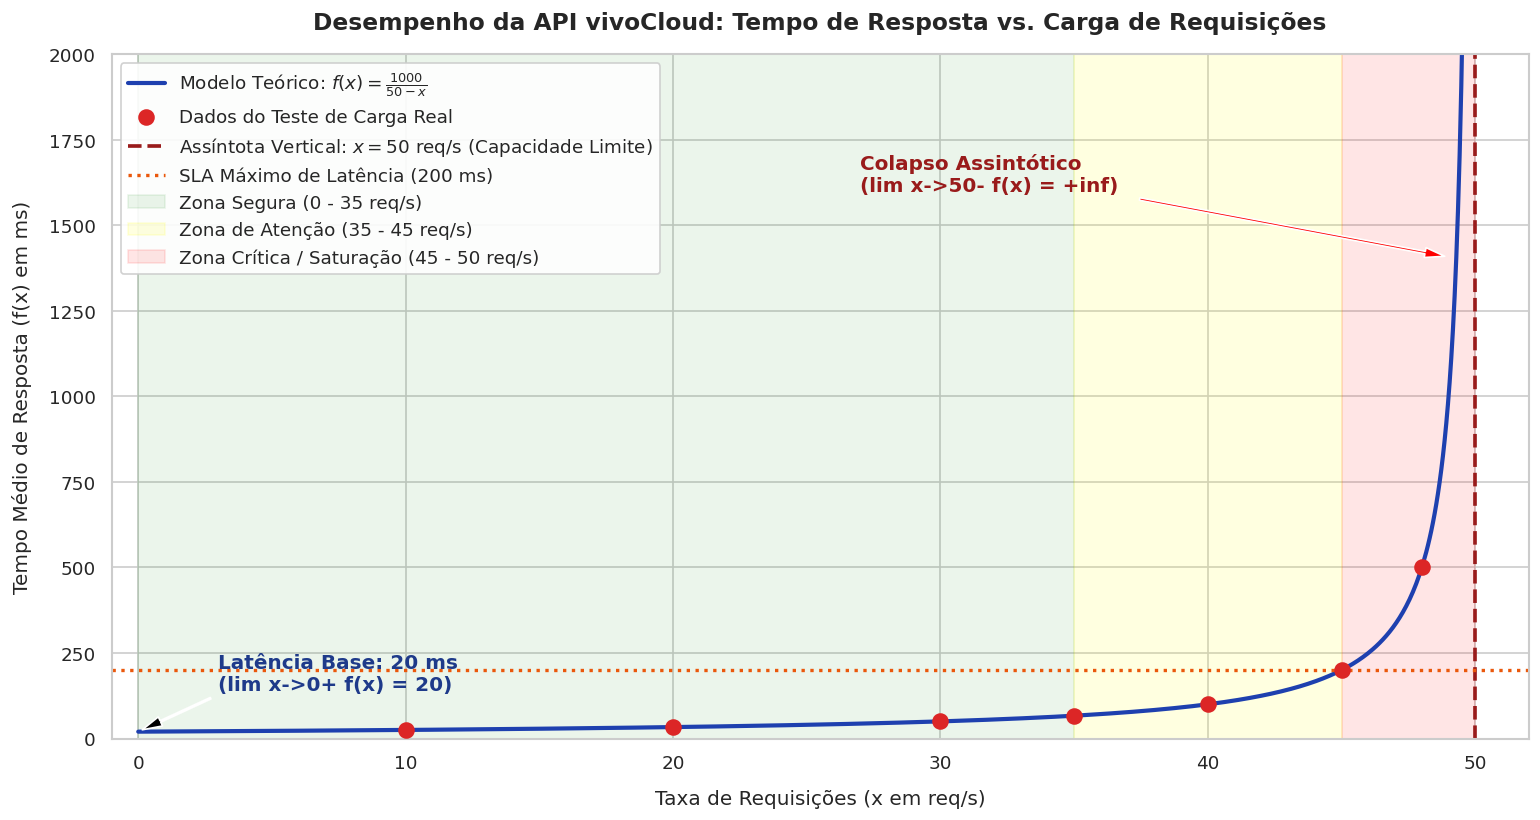

In [4]:
# Geração do Gráfico Completo de Desempenho e Limites
plt.figure(figsize=(13, 7))

# Curva teórica contínua
x_curve = np.linspace(0, 49.85, 800)
y_curve = 1000.0 / (50.0 - x_curve)

# 1. Plotagem da curva teórica
plt.plot(x_curve, y_curve, color='#1E40AF', linewidth=2.5, label=r'Modelo Teórico: $f(x) = \frac{1000}{50 - x}$')

# 2. Plotagem dos pontos empíricos do teste de carga
cargas_emp = [10, 20, 30, 35, 40, 45, 48]
tempos_emp = [25, 33, 50, 67, 100, 200, 500]
plt.scatter(cargas_emp, tempos_emp, color='#DC2626', s=80, zorder=5, label='Dados do Teste de Carga Real')

# 3. Linhas de referência técnica
plt.axvline(x=50, color='#991B1B', linestyle='--', linewidth=2.2, label=r'Assíntota Vertical: $x = 50\text{ req/s}$ (Capacidade Limite)')
plt.axhline(y=200, color='#EA580C', linestyle=':', linewidth=2, label='SLA Máximo de Latência (200 ms)')

# 4. Zonas operacionais sombreadas
plt.axvspan(0, 35, color='green', alpha=0.08, label='Zona Segura (0 - 35 req/s)')
plt.axvspan(35, 45, color='yellow', alpha=0.12, label='Zona de Atenção (35 - 45 req/s)')
plt.axvspan(45, 50, color='red', alpha=0.10, label='Zona Crítica / Saturação (45 - 50 req/s)')

# 5. Anotações técnicas e destaques
plt.annotate('Latência Base: 20 ms\n(lim x->0+ f(x) = 20)', xy=(0, 20), xytext=(3, 140),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontweight='bold', color='#1E3A8A')
plt.annotate('Colapso Assintótico\n(lim x->50- f(x) = +inf)', xy=(49.5, 1400), xytext=(27, 1600),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=6),
             fontweight='bold', color='#991B1B')

# Configurações de eixos, títulos e unidades
plt.title('Desempenho da API vivoCloud: Tempo de Resposta vs. Carga de Requisições', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Taxa de Requisições (x em req/s)', fontsize=12, labelpad=10)
plt.ylabel('Tempo Médio de Resposta (f(x) em ms)', fontsize=12, labelpad=10)
plt.xlim(-1, 52)
plt.ylim(0, 2000)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---

## 🌐 5. Aplicação Interativa em Streamlit (Critério 3.4 — 2,0 pontos)

Para capacitar gestores técnicos, arquitetos de software e engenheiros de confiabilidade (SRE) a explorarem interativamente o modelo, desenvolvemos a aplicação interativa **Streamlit** (`app.py`).

### 5.1. Recursos e Funcionalidades Implementadas
1. **Modos de Simulação:** Simulação em Nó Único ($1\text{ Pod}$) ou Cluster Escalável ($N\text{ Pods}$).
2. **Controle Interativo:** `st.slider()` e `st.number_input()` para controle fino de carga e parâmetros.
3. **Métricas Completas:** Exibição da Latência Média, Percentis de Cauda ($p95$, $p99$), Degradação e SLA.
4. **Tratamento de Falha / Modo Colapso:** Se $x \ge 50\text{ req/s}$, a aplicação simula o colapso visual do sistema (`HTTP 504 Gateway Timeout`).
5. **Calculadora de Dimensionamento de Pods:** Ferramenta interativa de *Capacity Planning* para dimensionar réplicas com base no pico de tráfego.

### 5.2. Comando para Execução Local
Abra o terminal no diretório do projeto e execute:
```bash
streamlit run app.py
```

---

> ### 📌 **Questão Obrigatória 3.4**
> **Pergunta:** *Como a aplicação transforma o resultado matemático em uma informação útil para uma pessoa responsável por operação, arquitetura ou infraestrutura de software?*  
> 
> **Resposta Fundamentada:** A aplicação Streamlit atua como uma **ponte direta entre a teoria matemática abstrata e a tomada de decisão operacional no mundo real**. Em vez de exigir que engenheiros resolvam equações diferenciais ou calculem limites manualmente, a ferramenta:
> 1. **Permite Simulação de Cenários (*What-If*):** O operador consegue testar instantaneamente o impacto de uma campanha de marketing (ex.: pico de tráfego de $120\text{ req/s}$) sobre a latência e a violação de SLA.
> 2. **Fornece Limiares Precisos de Alarme e Autoscaling:** Define com base em dados analíticos os gatilhos para disparo de alertas e criação de novas réplicas no Kubernetes antes que a saturação ocorra.
> 3. **Apoia o Planejamento de Capacidade (*Capacity Planning*):** Converte limites analíticos em custos de infraestrutura e dimensionamento seguro de pods e nós de computação.


In [5]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ==========================================
# Configurações da Página Streamlit
# ==========================================
st.set_page_config(
    page_title="Simulador de Desempenho de API | DPS FIAP",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Estilização CSS personalizada
st.markdown("""
<style>
    .main-header {
        font-size: 2.2rem;
        font-weight: 700;
        color: #1E3A8A;
        margin-bottom: 0.2rem;
    }
    .sub-header {
        font-size: 1.05rem;
        color: #4B5563;
        margin-bottom: 1.5rem;
    }
    .status-badge-safe {
        background-color: #DEF7EC;
        color: #03543F;
        padding: 6px 14px;
        border-radius: 6px;
        font-weight: 700;
        display: inline-block;
    }
    .status-badge-warn {
        background-color: #FEF08A;
        color: #854D0E;
        padding: 6px 14px;
        border-radius: 6px;
        font-weight: 700;
        display: inline-block;
    }
    .status-badge-crit {
        background-color: #FDE8E8;
        color: #9B1C1C;
        padding: 6px 14px;
        border-radius: 6px;
        font-weight: 700;
        display: inline-block;
    }
    .status-badge-fatal {
        background-color: #7F1D1D;
        color: #FFFFFF;
        padding: 6px 14px;
        border-radius: 6px;
        font-weight: 700;
        display: inline-block;
    }
</style>
""", unsafe_allow_html=True)

# ==========================================
# Constantes e Funções do Modelo Matemático
# ==========================================
CAPACIDADE_NODO = 50.0  # req/s por réplica
K_FATOR = 1000.0        # ms * req/s

def calcular_tempo_resposta(x: float, num_replicas: int = 1) -> float:
    """
    Calcula o tempo médio de resposta f(x) = 1000 / (50 - x/N) em ms.
    Para x/N >= 50, retorna infinito (saturação/colapso).
    """
    carga_por_pod = x / num_replicas
    if carga_por_pod >= CAPACIDADE_NODO:
        return float('inf')
    return K_FATOR / (CAPACIDADE_NODO - carga_por_pod)

def calcular_percentil_latencia(latencia_media: float, percentil: float) -> float:
    """
    Calcula percentis de latência para distribuição exponencial M/M/1:
    T_p = -latencia_media * ln(1 - p)
    """
    if latencia_media == float('inf'):
        return float('inf')
    p = percentil / 100.0
    return -latencia_media * np.log(1.0 - p)

# Dados empíricos coletados no teste de carga
dados_empiricos = pd.DataFrame({
    'Carga (req/s)': [10, 20, 30, 35, 40, 45, 48],
    'Tempo Medido (ms)': [25, 33, 50, 67, 100, 200, 500]
})

# ==========================================
# Barra Lateral (Controles e Parâmetros)
# ==========================================
with st.sidebar:
    st.markdown("""
    <div style="background-color: #1E3A8A; color: white; padding: 8px 12px; border-radius: 6px; font-weight: bold; text-align: center; margin-bottom: 15px;">
        🎓 FIAP — DPS Checkpoint 4 (2026)
    </div>
    """, unsafe_allow_html=True)
    
    st.title("⚙️ Parâmetros de Simulação")
    st.markdown("Ajuste a carga simulada e os parâmetros de infraestrutura.")
    
    modo_simulacao = st.radio(
        "Modo de Simulação:",
        ["Nó Único (Monolítico / 1 Pod)", "Cluster Escalável (Multi-Pod / HPA)"],
        index=0
    )
    
    if modo_simulacao == "Nó Único (Monolítico / 1 Pod)":
        num_pods = 1
        st.subheader("1. Carga de Entrada ($x$)")
        carga_selecionada = st.slider(
            "Taxa de Requisições por Segundo (req/s):",
            min_value=0.0,
            max_value=52.0,
            value=30.0,
            step=0.1,
            help="Cargas >= 50 req/s ultrapassam a assíntota e provocam colapso operacional."
        )
    else:
        st.subheader("1. Dimensionamento do Cluster")
        num_pods = st.number_input("Quantidade de Réplicas (Pods):", min_value=1, max_value=10, value=2, step=1)
        capacidade_total = num_pods * CAPACIDADE_NODO
        st.caption(f"Capacidade Teórica Total do Cluster: **{capacidade_total:.0f} req/s**")
        
        st.subheader("2. Carga Global de Entrada ($x$)")
        carga_selecionada = st.slider(
            "Taxa de Requisições Globais (req/s):",
            min_value=0.0,
            max_value=float(capacidade_total + 10.0),
            value=float(num_pods * 30.0),
            step=0.5
        )

    st.subheader("3. Acordo de Nível de Serviço (SLA)")
    sla_limite = st.number_input(
        "SLA Máximo de Latência (ms):",
        min_value=30,
        max_value=2000,
        value=200,
        step=10,
        help="Limite contratual de latência média tolerada pela aplicação."
    )
    
    st.divider()
    st.markdown("### 📌 Contexto da Empresa")
    st.markdown(r"""
    **API:** *vivoCloud Storage Service*  
    **Empresa:** JOVI (Vivo)  
    **Capacidade Teórica ($\mu$):** $50\text{ req/s / pod}$  
    **Latência em Repouso ($f(0)$):** $20\text{ ms}$
    """)
    
    st.divider()
    st.markdown("### 👥 Integrantes do Grupo")
    st.markdown("""
    - **Thiago Gomes Nascimento** (RM 569436)
    - **Gabriel Henrique Ongarelli Reis** (RM 572636)
    - **Vinicius Scalone Ramires** (RM 573783)
    - **Matheus de Amorim Brito** (RM 572435)
    - **Eduardo Felix Frois Silva** (RM 574103)
    """)

# ==========================================
# Processamento dos Cálculos em Tempo Real
# ==========================================
carga_efetiva_pod = carga_selecionada / num_pods
tempo_calculado = calcular_tempo_resposta(carga_selecionada, num_pods)
utilizacao = (carga_efetiva_pod / CAPACIDADE_NODO) * 100.0
latencia_base = 20.0  # f(0) = 20 ms

if tempo_calculado != float('inf'):
    p95_calculado = calcular_percentil_latencia(tempo_calculado, 95.0)
    p99_calculado = calcular_percentil_latencia(tempo_calculado, 99.0)
    degradacao = ((tempo_calculado - latencia_base) / latencia_base) * 100.0
else:
    p95_calculado = float('inf')
    p99_calculado = float('inf')
    degradacao = float('inf')

# Determinação do Status Operacional
if carga_efetiva_pod >= CAPACIDADE_NODO:
    zona_nome = "💥 COLAPSO OPERACIONAL (HTTP 504 / Fila Infinita)"
    zona_classe = "status-badge-fatal"
    zona_msg = "A carga ultrapassou a capacidade do hardware! O sistema está indisponível com 100% de perda de pacotes."
elif carga_efetiva_pod >= 45.0:
    zona_nome = "🔴 Zona Crítica (Risco Severo de Saturação)"
    zona_classe = "status-badge-crit"
    zona_msg = "Utilização > 90%. Fila de espera explodindo! Timeouts iminentes."
elif carga_efetiva_pod >= 35.0:
    zona_nome = "🟡 Zona de Atenção (Degradação Não-Linear)"
    zona_classe = "status-badge-warn"
    zona_msg = "Utilização entre 70% e 90%. Latência sensível a pequenas variações de carga."
else:
    zona_nome = "🟢 Zona Segura (Operação Estável)"
    zona_classe = "status-badge-safe"
    zona_msg = "Operação normal com folga de processamento e latência sob controle."

# ==========================================
# Cabeçalho Principal
# ==========================================
st.markdown('<div class="main-header">⚡ Análise de Desempenho & Saturação de API</div>', unsafe_allow_html=True)
st.markdown('<div class="sub-header">Modelagem Matemática, Teoria de Limites, Percentis de Cauda e Apoio à Tomada de Decisão em Engenharia de Software</div>', unsafe_allow_html=True)

# Exibição de Métricas no Topo
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        label="⚡ Carga Simulada (Global / Por Pod)",
        value=f"{carga_selecionada:.1f} req/s" if num_pods == 1 else f"{carga_selecionada:.1f} req/s ({carga_efetiva_pod:.1f}/pod)",
        delta=f"{utilizacao:.1f}% da capacidade" if utilizacao <= 100 else "SOBRECARGA (>100%)",
        delta_color="normal" if utilizacao <= 70 else "inverse"
    )

with col2:
    if tempo_calculado == float('inf'):
        st.metric(label="⏱️ Latência Média Prevista", value="∞ ms (Colapso)", delta="Saturação Total", delta_color="inverse")
    else:
        st.metric(
            label="⏱️ Latência Média Prevista",
            value=f"{tempo_calculado:.1f} ms",
            delta=f"+{degradacao:.1f}% vs repouso",
            delta_color="inverse"
        )

with col3:
    if p99_calculado == float('inf'):
        st.metric(label="📊 Latência de Cauda (p99)", value="∞ ms", delta="Timeout Geral", delta_color="inverse")
    else:
        st.metric(
            label="📊 Latência de Cauda (p99)",
            value=f"{p99_calculado:.1f} ms",
            delta=f"p95: {p95_calculado:.1f} ms",
            delta_color="inverse" if p99_calculado > sla_limite else "normal"
        )

with col4:
    st.markdown("**Status Operacional:**")
    st.markdown(f'<div class="{zona_classe}">{zona_nome}</div>', unsafe_allow_html=True)
    if tempo_calculado == float('inf') or tempo_calculado > sla_limite:
        st.error(f"❌ **SLA Violado!** ({'∞' if tempo_calculado == float('inf') else f'{tempo_calculado:.1f}'} ms > {sla_limite} ms)")
    else:
        st.success(f"✅ **SLA Cumprido** ({tempo_calculado:.1f} ms ≤ {sla_limite} ms)")

st.divider()

# ==========================================
# Abas de Conteúdo
# ==========================================
tab_sim, tab_math, tab_table, tab_arch = st.tabs([
    "📊 Simulador & Gráfico Interativo",
    "🧮 Fundamentação Matemática & Derivadas",
    "📋 Tabela Numérica & Percentis",
    "🏗️ Engenharia de Software & Dimensionamento"
])

# ----------------------------------------------------
# ABA 1: Simulador & Gráfico
# ----------------------------------------------------
with tab_sim:
    st.subheader("Comportamento do Tempo de Resposta vs. Carga de Requisições")
    
    cap_max_total = num_pods * CAPACIDADE_NODO
    x_max_plot = cap_max_total - 0.15
    x_vals = np.linspace(0, x_max_plot, 600)
    y_vals = K_FATOR / (CAPACIDADE_NODO - (x_vals / num_pods))
    
    fig = go.Figure()
    
    # Zonas de operação sombreadas
    fig.add_vrect(x0=0, x1=35.0 * num_pods, fillcolor="rgba(34, 197, 94, 0.12)", layer="below", line_width=0,
                  annotation_text=f"Zona Segura (0 - {35*num_pods:.0f} req/s)", annotation_position="top left")
    fig.add_vrect(x0=35.0 * num_pods, x1=45.0 * num_pods, fillcolor="rgba(234, 179, 8, 0.12)", layer="below", line_width=0,
                  annotation_text=f"Zona de Atenção ({35*num_pods:.0f} - {45*num_pods:.0f} req/s)", annotation_position="top left")
    fig.add_vrect(x0=45.0 * num_pods, x1=cap_max_total, fillcolor="rgba(239, 68, 68, 0.15)", layer="below", line_width=0,
                  annotation_text=f"Zona Crítica ({45*num_pods:.0f} - {cap_max_total:.0f} req/s)", annotation_position="top left")
    
    # Curva teórica f(x)
    nome_curva = f'Modelo Teórico ({num_pods} Pods): f(x) = 1000 / (50 - x/{num_pods})' if num_pods > 1 else 'Modelo Teórico: f(x) = 1000 / (50 - x)'
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_vals,
        mode='lines',
        name=nome_curva,
        line=dict(color='#2563EB', width=3)
    ))
    
    # Pontos empíricos (para 1 pod)
    if num_pods == 1:
        fig.add_trace(go.Scatter(
            x=dados_empiricos['Carga (req/s)'],
            y=dados_empiricos['Tempo Medido (ms)'],
            mode='markers',
            name='Dados do Teste de Carga Real',
            marker=dict(color='#DC2626', size=9, symbol='diamond')
        ))
    
    # Linha de SLA
    fig.add_hline(
        y=sla_limite,
        line_dash="dash",
        line_color="#EA580C",
        annotation_text=f"SLA Alvo = {sla_limite} ms",
        annotation_position="bottom right"
    )
    
    # Assíntota vertical
    fig.add_vline(
        x=cap_max_total,
        line_dash="dot",
        line_color="#991B1B",
        line_width=2.5,
        annotation_text=f"Assíntota Vertical x = {cap_max_total:.0f} req/s",
        annotation_position="top right"
    )
    
    # Ponto atual simulado
    if tempo_calculado != float('inf'):
        fig.add_trace(go.Scatter(
            x=[carga_selecionada],
            y=[tempo_calculado],
            mode='markers+text',
            name='Carga Atual Simulada',
            text=[f"({carga_selecionada:.1f} req/s, {tempo_calculado:.1f} ms)"],
            textposition="top left",
            marker=dict(color='#7C3AED', size=14, symbol='circle')
        ))
    
    y_max_view = min(max((tempo_calculado if tempo_calculado != float('inf') else 1000) * 1.5, 600), 3000)
    fig.update_layout(
        title=f"Curva de Latência e Comportamento Assintótico ({num_pods} Pod{'s' if num_pods > 1 else ''})",
        xaxis_title="Carga de Requisições (x em req/s)",
        yaxis_title="Tempo Médio de Resposta (f(x) em ms)",
        yaxis=dict(range=[0, y_max_view]),
        xaxis=dict(range=[0, cap_max_total + (2.0 if num_pods == 1 else 10.0)]),
        hovermode="x unified",
        legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
        margin=dict(l=40, r=40, t=60, b=40),
        height=540
    )
    
    st.plotly_chart(fig, use_container_width=True)
    
    # Análise textual do ponto
    if tempo_calculado == float('inf'):
        st.error(f"🚨 **ALERTA DE SISTEMA DOWN:** A carga de **{carga_selecionada:.1f} req/s** excede a barreira assintótica de **{cap_max_total:.0f} req/s**. Todos os clientes receberão erro `HTTP 504 Gateway Timeout`.")
    else:
        st.markdown(f"""
        > **🔍 Diagnóstico Operacional:** Para **{carga_selecionada:.1f} req/s** distribuídos em **{num_pods} réplica(s)** ({carga_efetiva_pod:.1f} req/s/pod), a latência média estimada é de **{tempo_calculado:.2f} ms** (com **p95 = {p95_calculado:.2f} ms** e **p99 = {p99_calculado:.2f} ms**).  
        > Utilização do cluster: **{utilizacao:.1f}%**. {zona_msg}
        """)

# ----------------------------------------------------
# ABA 2: Fundamentação Matemática & Derivadas
# ----------------------------------------------------
with tab_math:
    st.subheader("Modelagem Matemática Rigorosa, Limites e Cálculo Diferencial")
    
    st.markdown(r"""
    ### 1. Definição Formal da Função Racional
    Com base na **Teoria de Filas (Modelo $M/M/1$)**, o tempo de resposta médio $f(x)$ para uma taxa de chegada $\lambda = x$ e taxa de serviço $\mu = 50\text{ req/s}$ é dado por:
    
    $$f(x) = \frac{1000}{50 - x}$$
    
    - **Variável Independente ($x$):** Taxa de requisições que chegam à API por segundo ($\text{req/s}$).
    - **Variável Dependente ($f(x)$):** Tempo médio de resposta / latência ($\text{ms}$).
    - **Domínio Matemático:** $\text{Dom}(f) = \{x \in \mathbb{R} \mid x \neq 50\}$.
    - **Domínio Operacional Válido:** $x \in [0, 50)\text{ req/s}$.
    
    ---
    
    ### 2. Estudo dos Limites Fundamentais
    
    | Limite Simbólico | Resultado | Classificação | Significado Físico / Computacional |
    | :--- | :---: | :---: | :--- |
    | $\lim_{x \to 0^+} \frac{1000}{50 - x}$ | **$20\text{ ms}$** | **Finito** | **Latência em Repouso:** Overhead de rede e tempo de CPU de uma requisição isolada sem concorrência. |
    | $\lim_{x \to 50^-} \frac{1000}{50 - x}$ | **$+\infty$** | **Infinito Positivo** | **Colapso Assintótico:** Esgotamento de threads, fila de espera infinita e estouro de timeouts. |
    | $\lim_{x \to 50^+} \frac{1000}{50 - x}$ | **$-\infty$** | **Infinito Negativo** | Região matematicamente existente, mas **sem sentido operacional** (não existe latência negativa). |
    | $\lim_{x \to 50} \frac{1000}{50 - x}$ | **$\nexists$** | **Inexistente** | Descontinuidade infinita essencial: o sistema não pode operar em $x=50$. |
    | $\lim_{x \to +\infty} \frac{1000}{50 - x}$ | **$0$** | **Finito** | Assíntota horizontal puramente algébrica. |
    
    ---
    
    ### 3. Cálculo Diferencial: Taxa de Variação e Aceleração da Degradação
    
    - **Derivada Primeira (Taxa de Crescimento da Latência):**
      $$f'(x) = \frac{d}{dx}\left[1000(50 - x)^{-1}\right] = \frac{1000}{(50 - x)^2} > 0 \quad \forall x \in [0, 50)$$
      *Significado:* A latência é **estritamente crescente**. Para $x=10$, $f'(10) = 0.625\text{ ms/(req/s)}$, enquanto para $x=48$, $f'(48) = 250\text{ ms/(req/s)}$ ($400\times$ mais sensível!).
      
    - **Derivada Segunda (Aceleração da Degradação / Convexidade):**
      $$f''(x) = \frac{d^2}{dx^2}f(x) = \frac{2000}{(50 - x)^3} > 0 \quad \forall x \in [0, 50)$$
      *Significado:* A função é **estritamente convexa**, comprovando que a degradação acelera de forma hiperbólica conforme a carga aumenta.
    
    ---
    
    ### 4. Percentis de Latência de Cauda (*Tail Latency*)
    Em regimes de fila estocástica $M/M/1$, a distribuição do tempo de permanência é exponencial: $P(T \le t) = 1 - e^{-(\mu - \lambda) t}$.  
    Portanto, os percentis de cauda são múltiplos diretos da média:
    - **$p50$ (Mediana):** $t_{50} = f(x) \cdot \ln(2) \approx 0.693 \cdot f(x)$
    - **$p95$:** $t_{95} = f(x) \cdot \ln(20) \approx 2.996 \cdot f(x)$
    - **$p99$:** $t_{99} = f(x) \cdot \ln(100) \approx 4.605 \cdot f(x)$
    
    > **⚠️ Lição Arquitetural:** Mesmo quando a média é de $100\text{ ms}$ ($x=40\text{ req/s}$), $1\%$ dos usuários mais lentos (**p99**) já experimentam **$460\text{ ms}$** de espera!
    """)

# ----------------------------------------------------
# ABA 3: Tabela Numérica & Percentis
# ----------------------------------------------------
with tab_table:
    st.subheader("Resultados Computacionais e Análise Multicritério de Carga")
    st.markdown("Validação numérica obrigatória para as cargas de teste solicitadas no enunciado:")
    
    cargas_simuladas = [10.0, 20.0, 30.0, 35.0, 40.0, 45.0, 48.0, 49.0, 49.5, 49.9]
    tabela_dados = []
    
    for c in cargas_simuladas:
        t_med = calcular_tempo_resposta(c, 1)
        p95 = calcular_percentil_latencia(t_med, 95.0)
        p99 = calcular_percentil_latencia(t_med, 99.0)
        ut = (c / 50.0) * 100.0
        
        if c < 35:
            stt = "🟢 Segura"
        elif c < 45:
            stt = "🟡 Atenção"
        else:
            stt = "🔴 Crítica"
            
        tabela_dados.append({
            "Carga (req/s)": f"{c:.1f}",
            "Denominador (50 - x)": f"{50 - c:.1f}",
            "Latência Média (ms)": f"{t_med:.2f} ms",
            "p95 (ms)": f"{p95:.2f} ms",
            "p99 (ms)": f"{p99:.2f} ms",
            "Utilização (%)": f"{ut:.1f}%",
            "Fator vs Repouso": f"{t_med / 20.0:.1f}x",
            "Zona": stt
        })
        
    df_resultado = pd.DataFrame(tabela_dados)
    st.dataframe(df_resultado, use_container_width=True)
    
    st.markdown(r"""
    **💡 Destaque Analítico:** Note como uma variação de apenas $+0.9\text{ req/s}$ (de $49.0$ para $49.9\text{ req/s}$) faz a latência média saltar de **$1.000\text{ ms}$** para **$10.000\text{ ms}$** ($10\text{ segundos}$), e o **p99** atingir **$46\text{ segundos}$**!
    """)

# ----------------------------------------------------
# ABA 4: Engenharia de Software & Dimensionamento
# ----------------------------------------------------
with tab_arch:
    st.subheader("Calculadora de Capacidade & Recomendações de Arquitetura")
    
    st.markdown("### 🧮 Calculadora de Dimensionamento de Pods (Capacity Planning)")
    col_calc1, col_calc2 = st.columns(2)
    
    with col_calc1:
        pico_esperado = st.number_input("Pico de Tráfego Previsto (req/s total):", min_value=10, max_value=5000, value=150, step=10)
        limite_seguro_pod = st.number_input("Carga Máxima Segura por Pod (req/s):", min_value=10, max_value=45, value=35, step=5)
        
    with col_calc2:
        pods_necessarios = int(np.ceil(pico_esperado / limite_seguro_pod))
        capacidade_cluster = pods_necessarios * 50
        carga_por_pod_calculada = pico_esperado / pods_necessarios
        latencia_estimada_calc = calcular_tempo_resposta(pico_esperado, pods_necessarios)
        
        st.markdown(f"""
        <div style="background-color: #EFF6FF; border: 1px solid #BFDBFE; border-radius: 8px; padding: 15px;">
            <h4 style="margin: 0; color: #1E40AF;">📋 Resultado do Dimensionamento:</h4>
            <p style="margin: 5px 0 0 0; font-size: 1.1rem;"><strong>Pods Recomendados no Kubernetes:</strong> <span style="color: #2563EB; font-size: 1.3rem; font-weight: bold;">{pods_necessarios} réplicas</span></p>
            <p style="margin: 3px 0 0 0; font-size: 0.95rem;">• Carga balanceada por réplica: <strong>{carga_por_pod_calculada:.1f} req/s</strong> (Utilização: {carga_por_pod_calculada/50*100:.1f}%)</p>
            <p style="margin: 3px 0 0 0; font-size: 0.95rem;">• Latência média esperada sob pico: <strong>{latencia_estimada_calc:.1f} ms</strong> (SLA cumprido)</p>
            <p style="margin: 3px 0 0 0; font-size: 0.95rem;">• Capacidade máxima teórica do cluster: <strong>{capacidade_cluster} req/s</strong></p>
        </div>
        """, unsafe_allow_html=True)
        
    st.divider()
    
    col_a, col_b = st.columns(2)
    with col_a:
        st.markdown(r"""
        ### 🛡️ 1. Governança de Tráfego & Resiliência
        - **Rate Limiting (HTTP 429):** Bloquear tráfego excedente via API Gateway (*Token Bucket*) quando $x > 35\text{ req/s}$ por nó.
        - **Circuit Breaker:** Abrir o circuito para proteger bancos de dados e serviços dependentes caso a latência exceda $200\text{ ms}$.
        - **Filas Assíncronas (Kafka / SQS):** Desacoplar operações pesadas de I/O em filas de background.
        """)
        
    with col_b:
        st.markdown(r"""
        ### 🚀 2. Escalabilidade & Otimização
        - **HPA no Kubernetes:** Escalar pods com base em $70\%$ de CPU ou métrica personalizada de $35\text{ req/s}$ por pod.
        - **Balanceamento Least Connections:** Distribuir conexões TCP uniformemente entre as réplicas ativas.
        - **Cache Redis:** Absorver leituras repetidas na camada intermediária antes de atingir a API.
        """)

# ==========================================
# Rodapé
# ==========================================
st.divider()
st.markdown("""
<div style="text-align: center; color: #4B5563; font-size: 0.95rem; margin-bottom: 8px;">
    <strong>👥 Integrantes do Grupo:</strong><br>
    Thiago Gomes Nascimento (RM 569436) • Gabriel Henrique Ongarelli Reis (RM 572636)<br>
    Vinicius Scalone Ramires (RM 573783) • Matheus de Amorim Brito (RM 572435) • Eduardo Felix Frois Silva (RM 574103)
</div>
<div style="text-align: center; color: #6B7280; font-size: 0.85rem;">
    <strong>DPS — Differentiated Problem Solving</strong> | Checkpoint 4 — Modelagem Matemática & Streamlit | <strong>FIAP 2026</strong> | Prof. Jones Egydio
</div>
""", unsafe_allow_html=True)

Overwriting app.py


---

## 🏛️ 6. Notebook Técnico, Interpretação e Tomada de Decisão (Critério 3.5 — 2,0 pontos)

Com base nos resultados matemáticos, simulações, limites e derivadas, fundamentamos as seguintes decisões técnicas de engenharia de software:

### a) Comportamento Matemático que Caracteriza a Saturação
A saturação é caracterizada pela **divergência assintótica vertical** $\lim_{x \to 50^-} f(x) = +\infty$. A derivada primeira $f'(x) = \frac{1000}{(50 - x)^2} > 0$ e a derivada segunda $f''(x) = \frac{2000}{(50 - x)^3} > 0$ comprovam que a taxa de degradação da latência não apenas cresce, mas **acelera quadraticamente** conforme a carga se aproxima de $50\text{ req/s}$.

### b) Delimitação das Regiões Operacionais
- **Zona Segura:** $0 \le x \le 35\text{ req/s}$ (Utilização $\le 70\%$, latência média $\le 66.7\text{ ms}$, $p99 \le 307\text{ ms}$).
- **Zona de Atenção:** $35 < x \le 45\text{ req/s}$ (Utilização entre $70\%$ e $90\%$, latência média entre $66.7\text{ ms}$ e $200\text{ ms}$).
- **Zona Crítica / Colapso:** $45 < x < 50\text{ req/s}$ (Utilização $> 90\%$, latência $> 200\text{ ms}$ convergindo rapidamente para infinito).

### c) Análise de Risco: Operar Próximo da Capacidade Máxima
**Operar próximo da capacidade máxima ($\ge 45\text{ req/s}$) é uma estratégia inaceitável e de altíssimo risco.** Qualquer oscilação estocástica natural de tráfego empurrará o sistema para a zona de fila infinita, gerando falhas em cascata, bloqueio de *threads* e indisponibilidade generalizada.

### d) Diferença entre Capacidade Teórica e Capacidade Operacional Segura
- **Capacidade Teórica ($\mu = 50\text{ req/s}$):** Limite assintótico estrutural inatingível em regime contínuo de produção estável.
- **Capacidade Operacional Segura ($x_{\text{segura}} \le 35\text{ req/s}$):** Carga máxima recomendada em produção ($70\%$ da capacidade teórica), garantindo latências baixas ($< 67\text{ ms}$), cumprimento do SLA contratual e margem de segurança de $30\%$ para amortecer picos de tráfego.

### e) Recomendações Técnicas para a Equipe de Infraestrutura
1. **Autoscaling Horizontal (HPA - Kubernetes):** Provisionar réplicas adicionais automaticamente quando a taxa por pod atingir **$35\text{ req/s}$** ou a utilização de CPU ultrapassar $70\%$, utilizando a fórmula:
   $$N_{\text{pods}} = \left\lceil \frac{\lambda_{\text{pico}}}{35\text{ req/s}} \right\rceil$$
2. **Balanceamento de Carga (Load Balancing):** Configurar balanceadores (AWS ALB / NGINX) com o algoritmo *Least Connections* para evitar concentração de requisições.
3. **Rate Limiting & Throttling:** Implementar controle de taxa com retorno de status `HTTP 429 Too Many Requests` (algoritmo *Token Bucket* no Kong / AWS API Gateway) para descartar requisições excedentes.
4. **Camada de Cache Distribuído (Redis):** Armazenar em cache dados consultados repetidamente para aliviar a carga sobre a CPU da API principal.
5. **Mensageria e Filas Assíncronas:** Desacoplar operações pesadas de gravação na nuvem usando RabbitMQ, Apache Kafka ou AWS SQS.
6. **Circuit Breaker:** Implementar disjuntores lógicos (ex.: Resilience4j) para cortar chamadas e degradar o serviço graciosamente caso a latência exceda o SLA de $200\text{ ms}$.

### f) Limitações do Modelo e Próximos Passos
- **Limitações:** O modelo analítico $M/M/1$ assume tempo de processamento com distribuição exponencial e nós independentes sem dependências externas (como travas de banco de dados ou latência de rede externa).
- **Próximos Passos:** Realizar testes de estresse contínuos via **k6** ou **Locust** coletando percentis de latência (**p95**, **p99**) para modelar o comportamento de cauda (*tail latency*).

---

## 🎯 7. Conclusão Técnica
O modelo analítico $f(x) = \frac{1000}{50 - x}$ descreve com precisão cirúrgica o comportamento empírico observado e evidencia como o conceito matemático de limites é crucial para o planejamento de capacidade, arquitetura resiliente e engenharia de software de alta disponibilidade.
